In [ ]:
# -----------------------------------------------------------
# model setup
# -----------------------------------------------------------
import os, json, time, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_EPOCHS = 650
SEED       = 0
OUT_DIR    = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)
print('device:', DEVICE)

device: cpu


In [ ]:
# ------------------------------------------------------------
#  importing six GeoKAN variants
# ------------------------------------------------------------
import model_mlp
import model_efficient_kan
import model_geokan_gamma
import model_geokan_nnmetric
import model_lmkan_wav
import model_lmkan_rbf

MODELS = [model_mlp, model_efficient_kan, model_geokan_gamma,
          model_geokan_nnmetric, model_lmkan_wav, model_lmkan_rbf]
LOSERS = {'MLP', 'EfficientKAN'}   # plotted dashed

for m in MODELS:
    print(f'{m.NAME:18s}  color={m.COLOR}  epochs={m.HP["epochs"]}')

MLP                 color=#888888  epochs=600
EfficientKAN        color=#ff7f0e  epochs=600
GeoKAN-gamma        color=#2ca02c  epochs=600
GeoKAN-NNMetric     color=#1f77b4  epochs=600
LMKAN-Wav           color=#d62728  epochs=600
LMKAN-RBF           color=#9467bd  epochs=600


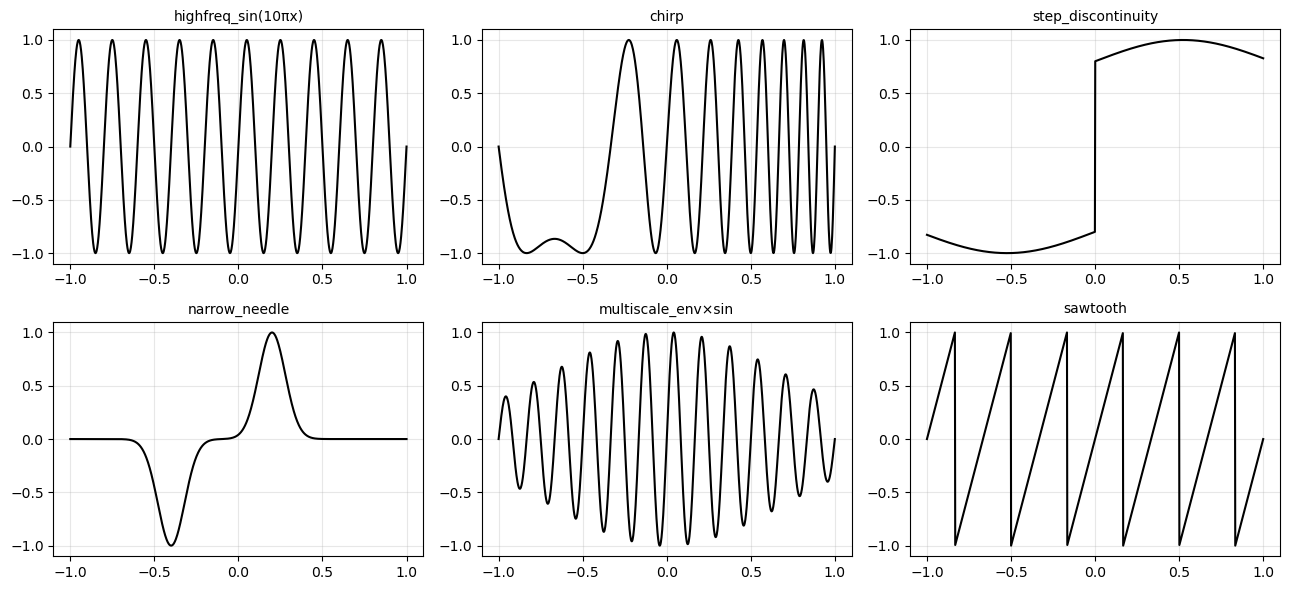

In [ ]:
# ----------------------------------------------------
# target functions
# ----------------------------------------------------
def f_highfreq(x):   return np.sin(10 * np.pi * x)
def f_chirp(x):      return np.sin(2 * np.pi * (1.0 + 6.0 * (x + 1) / 2) * x)
def f_step(x):       return np.sign(x) * 0.8 + 0.2 * np.sin(3 * x)
def f_needle(x):     return np.exp(-80 * (x - 0.2) ** 2) - np.exp(-80 * (x + 0.4) ** 2)
def f_multiscale(x): return np.exp(-x * x) * np.sin(12 * np.pi * x)
def f_sawtooth(x):   return 2 * (x * 3 - np.floor(x * 3 + 0.5))

TARGETS = {
    'highfreq_sin(10πx)':   f_highfreq,
    'chirp':                f_chirp,
    'step_discontinuity':   f_step,
    'narrow_needle':        f_needle,
    'multiscale_env×sin':   f_multiscale,
    'sawtooth':             f_sawtooth,
}

xv = np.linspace(-1, 1, 1000)
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (name, fn) in zip(axes.ravel(), TARGETS.items()):
    ax.plot(xv, fn(xv), 'k'); ax.set_title(name, fontsize=10); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

In [ ]:
# -------------------------------------------------------
#  training
# -------------------------------------------------------
def count_params(m): return sum(p.numel() for p in m.parameters())

def train_one(module, x_tr, y_tr, x_te, y_te, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    model = module.build_model().to(DEVICE)
    hp = module.HP
    opt = torch.optim.Adam(model.parameters(), lr=hp['lr'],
                           weight_decay=hp['weight_decay'])
    epochs = min(hp['epochs'], MAX_EPOCHS)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best = float('inf'); best_pred = None; stagn = 0
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = ((model(x_tr) - y_tr) ** 2).mean()
        if hasattr(model, 'regularization_loss'):
            loss = loss + 1e-4 * model.regularization_loss()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step(); sched.step()
        if ep % 5 == 0 or ep == epochs - 1:
            model.eval()
            with torch.no_grad():
                te = ((model(x_te) - y_te) ** 2).mean().item()
            if te < best - 1e-7:
                best = te; stagn = 0
                with torch.no_grad():
                    best_pred = model(x_te).cpu().numpy().ravel()
            else:
                stagn += 5
            if ep >= hp.get('min_epochs', 0) and stagn > hp.get('patience', 120):
                break
    return best, best_pred, count_params(model)

In [ ]:
# ------------------------------------------------------
# run the full sweep
# ------------------------------------------------------

# Configs derived analytically per model architecture
PARAM_OVERRIDES = {
    'MLP': dict(
        width=87, depth=2,                          # 87² + 4·87 + 1 = 7918
    ),
    'EfficientKAN': dict(
        layers=[1, 35, 35, 1],                      # 6·H² + 12·H = 7770 at H=35
        grid_size=3, spline_order=1,
    ),
    'GeoKAN-gamma': dict(
        width=53, depth=2, K=12,                    # 2W² + 44W + 40 ≈ 7990
    ),
    'GeoKAN-NNMetric': dict(
        width=23, depth=2, K=12, metric_hidden=8,   # 12W² + 58W + 202 ≈ 7884
    ),
    'LMKAN-Wav': dict(
        width=23, depth=2, K=12, metric_hidden=8,   # same shape ≈ 7884
    ),
    'LMKAN-RBF': dict(
        width=23, depth=2, K=12, metric_hidden=8, gamma=2.0,
    ),
}

# Apply overrides since models are big
for mod in MODELS:
    if mod.NAME in PARAM_OVERRIDES:
        mod.HP.update(PARAM_OVERRIDES[mod.NAME])
    mod.HP['epochs']     = 800
    mod.HP['min_epochs'] = 250
    mod.HP['patience']   = 150

# Also bump the global cap so overrides actually take effect
MAX_EPOCHS = 800





# override HP to ~20,000 params per model

PARAM_OVERRIDES = {
    'MLP': dict(
        width=140, depth=2,                         # 140² + 4·140 + 1 = 20161
    ),
    'EfficientKAN': dict(
        layers=[1, 57, 57, 1],                      # 6·57² + 12·57 = 20178
        grid_size=3, spline_order=1,
    ),
    'GeoKAN-gamma': dict(
        width=90, depth=2, K=12,                    # 2W² + 43W + 40 ≈ 20110
    ),
    'GeoKAN-NNMetric': dict(
        width=38, depth=2, K=12, metric_hidden=8,   # 12W² + 58W + 202 ≈ 19734
    ),
    'LMKAN-Wav': dict(
        width=38, depth=2, K=12, metric_hidden=8,   # ≈ 19734
    ),
    'LMKAN-RBF': dict(
        width=38, depth=2, K=12, metric_hidden=8, gamma=2.0,
    ),
}

for mod in MODELS:
    if mod.NAME in PARAM_OVERRIDES:
        mod.HP.update(PARAM_OVERRIDES[mod.NAME])
    mod.HP['epochs']     = 1500      # bigger models need more steps
    mod.HP['min_epochs'] = 400
    mod.HP['patience']   = 200

MAX_EPOCHS = 2000

print(f"{'Model':18s}  {'params':>7s}")
print('-' * 30)
for mod in MODELS:
    n = sum(p.numel() for p in mod.build_model().parameters())
    print(f'{mod.NAME:18s}  {n:7d}')




# cross checking and reporting actual parameter count
print(f"{'Model':18s}  {'params':>7s}")
print('-' * 30)
for mod in MODELS:
    n = sum(p.numel() for p in mod.build_model().parameters())
    print(f'{mod.NAME:18s}  {n:7d}')
x_tr = np.linspace(-1, 1, 400).reshape(-1, 1).astype(np.float32)
x_te = np.linspace(-1, 1, 1000).reshape(-1, 1).astype(np.float32)

results = {}
for tname, fn in TARGETS.items():
    y_tr = fn(x_tr).astype(np.float32); y_te = fn(x_te).astype(np.float32)
    xt_tr = torch.from_numpy(x_tr).to(DEVICE); yt_tr = torch.from_numpy(y_tr).to(DEVICE)
    xt_te = torch.from_numpy(x_te).to(DEVICE); yt_te = torch.from_numpy(y_te).to(DEVICE)
    results[tname] = {}
    print(f'\n=== {tname} ===')
    for mod in MODELS:
        t0 = time.time()
        mse, pred, n = train_one(mod, xt_tr, yt_tr, xt_te, yt_te, seed=SEED)
        dt = time.time() - t0
        results[tname][mod.NAME] = dict(mse=mse, pred=pred, n=n,
                                        color=mod.COLOR, time=dt)
        print(f'  {mod.NAME:18s}  params={n:5d}  MSE={mse:.3e}  ({dt:.1f}s)')

with open(os.path.join(OUT_DIR, 'results.json'), 'w') as f:
    json.dump({t: {m: {'mse': r['mse'], 'n': r['n']}
                   for m, r in md.items()} for t, md in results.items()},
              f, indent=2)

Model                params
------------------------------
MLP                   20161
EfficientKAN          20178
GeoKAN-gamma          20200
GeoKAN-NNMetric       19734
LMKAN-Wav             19734
LMKAN-RBF             19734
Model                params
------------------------------
MLP                   20161
EfficientKAN          20178
GeoKAN-gamma          20200
GeoKAN-NNMetric       19734
LMKAN-Wav             19734
LMKAN-RBF             19734

=== highfreq_sin(10πx) ===
  MLP                 params=20161  MSE=3.472e-01  (15.0s)
  EfficientKAN        params=20178  MSE=8.445e-03  (53.7s)
  GeoKAN-gamma        params=20200  MSE=7.487e-04  (49.8s)
  GeoKAN-NNMetric     params=19734  MSE=4.592e-05  (25.9s)
  LMKAN-Wav           params=19734  MSE=4.592e-05  (27.6s)
  LMKAN-RBF           params=19734  MSE=7.910e-04  (28.8s)

=== chirp ===
  MLP                 params=20161  MSE=2.384e-01  (8.4s)
  EfficientKAN        params=20178  MSE=1.670e-03  (33.9s)
  GeoKAN-gamma        params=202

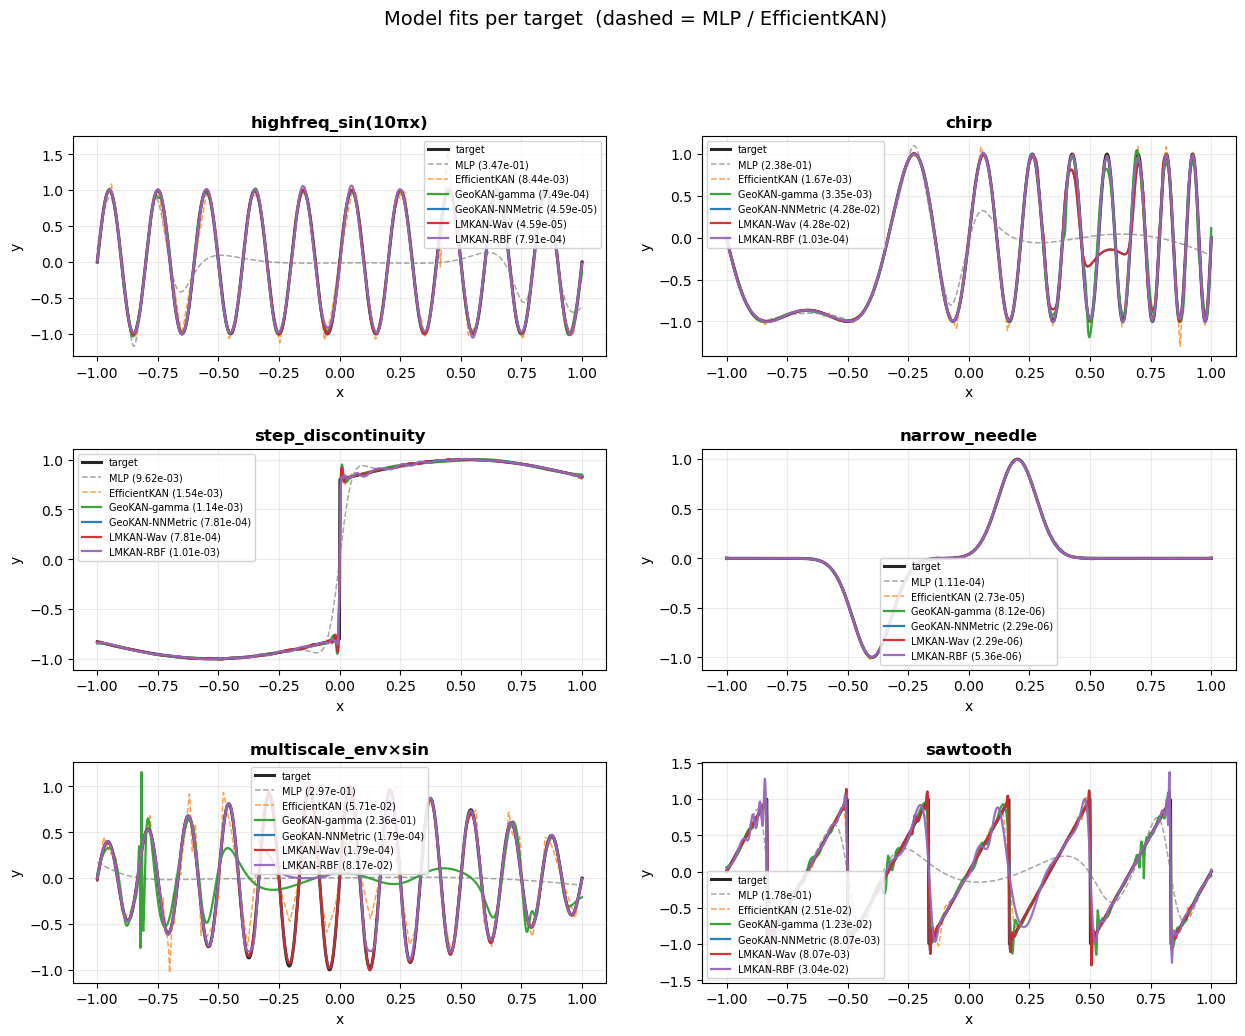

In [ ]:
# ----------------------------------------------------
# fitting plots
# ----------------------------------------------------
tasks = list(results.keys())
model_order = [m.NAME for m in MODELS]
x = x_te.ravel()

fig = plt.figure(figsize=(15, 11))
gs = GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.18)
for i, t in enumerate(tasks):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    y = TARGETS[t](x.reshape(-1, 1)).ravel()
    ax.plot(x, y, 'k', lw=2.2, label='target', alpha=0.85)
    for m in model_order:
        r = results[t][m]
        ls = '--' if m in LOSERS else '-'
        lw = 1.1 if m in LOSERS else 1.6
        a  = 0.75 if m in LOSERS else 0.95
        ax.plot(x, r['pred'], ls, color=r['color'], lw=lw, alpha=a,
                label=f"{m} ({r['mse']:.2e})")
    ax.set_title(t, fontsize=12, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=7, framealpha=0.85); ax.grid(alpha=0.25)
fig.suptitle('Model fits per target  (dashed = MLP / EfficientKAN)', fontsize=14, y=0.995)
fig.savefig(os.path.join(OUT_DIR, 'fits.png'), dpi=140, bbox_inches='tight')
plt.show()